In [7]:
!pip install -q --upgrade datasets huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.1/721.1 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.4 MB/s eta 0:00:00


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
import time

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
dataset = load_dataset("uoft-cs/cifar10")

x_train_full = np.array(dataset["train"]["img"])
y_train_full = np.array(dataset["train"]["label"]).reshape(-1, 1)
x_test = np.array(dataset["test"]["img"])
y_test = np.array(dataset["test"]["label"]).reshape(-1, 1)

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Full train:", x_train_full.shape)
print("Test:", x_test.shape)

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Full train: (50000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [3]:
val_size = 10000
x_train = x_train_full[:-val_size].astype('float32') / 255.0
y_train = y_train_full[:-val_size]
x_val = x_train_full[-val_size:].astype('float32') / 255.0
y_val = y_train_full[-val_size:]
x_test = x_test.astype('float32') / 255.0

print("Train:", x_train.shape)
print("Val:", x_val.shape)
print("Test:", x_test.shape)

Train: (40000, 32, 32, 3)
Val: (10000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [4]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

x_train_aug = data_augmentation(x_train, training=True).numpy()
x_train_combined = np.concatenate([x_train, x_train_aug], axis=0)
y_train_combined = np.concatenate([y_train, y_train], axis=0)

print("Augmented training set:", x_train_combined.shape)

Augmented training set: (80000, 32, 32, 3)


In [5]:
def build_improved_cnn(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)

    # Block 1 - 64 filters
    x = layers.Conv2D(64, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 2 - 128 filters
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 3 - 256 filters
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Fully Connected
    x = layers.Flatten()(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="improved_cnn")

improved_model = build_improved_cnn()
improved_model.summary()

Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 5,874,250 (22.41 MB)

 Trainable params: 5,872,458 (22.40 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [6]:
improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

history_improved = improved_model.fit(
    x_train_combined, y_train_combined,
    epochs=12,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

training_time_improved = time.time() - start_time
print(f"Training time: {training_time_improved:.2f} sec")
print(f"Epochs: {len(history_improved.history['accuracy'])}")

Epoch 1/12
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.3244 - loss: 1.8492 - val_accuracy: 0.4219 - val_loss: 1.5891
Epoch 2/12
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.4990 - loss: 1.3932 - val_accuracy: 0.5425 - val_loss: 1.2606
Epoch 3/12
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.5989 - loss: 1.1472 - val_accuracy: 0.6258 - val_loss: 1.0712
Epoch 4/12
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.6606 - loss: 0.9890 - val_accuracy: 0.6990 - val_loss: 0.9084
Epoch 5/12
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.7075 - loss: 0.8647 - val_accuracy: 0.6951 - val_loss: 0.9015
Epoch 6/12
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.7437 - loss: 0.7657 - val_accuracy: 0.7253 - val_loss: 0.8562
Epoch 7/12
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.7722 - loss: 0.6830 - val_accuracy: 0.7704 - val_loss: 0.7139
Epoch 8/12
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.7926 -

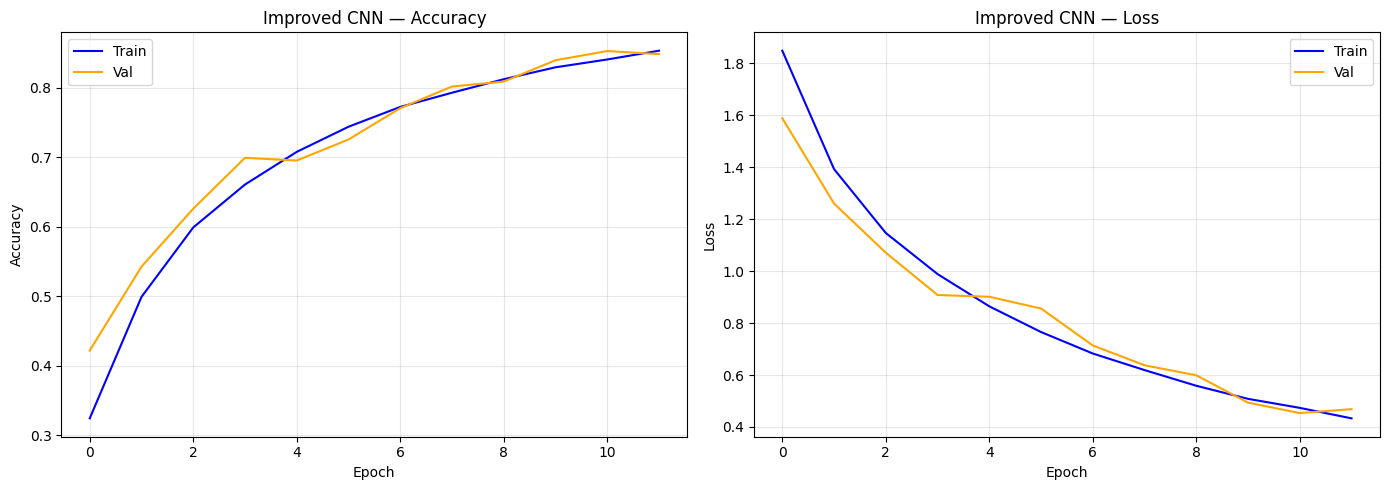

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_improved.history['accuracy'], label='Train', color='blue')
ax1.plot(history_improved.history['val_accuracy'], label='Val', color='orange')
ax1.set_title('Improved CNN — Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_improved.history['loss'], label='Train', color='blue')
ax2.plot(history_improved.history['val_loss'], label='Val', color='orange')
ax2.set_title('Improved CNN — Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('improved_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
test_loss_imp, test_acc_imp = improved_model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc_imp*100:.2f}%")
print(f"Test Loss: {test_loss_imp:.4f}")

y_pred_imp = improved_model.predict(x_test)
y_pred_classes_imp = np.argmax(y_pred_imp, axis=1)
y_true = y_test.flatten()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes_imp, target_names=class_names))

Test Accuracy: 84.94%
Test Loss: 0.4800
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

Classification Report:
              precision    recall  f1-score   support

    airplane       0.89      0.85      0.87      1000
  automobile       0.93      0.93      0.93      1000
        bird       0.78      0.82      0.80      1000
         cat       0.76      0.65      0.70      1000
        deer       0.86      0.82      0.84      1000
         dog       0.83      0.76      0.79      1000
        frog       0.78      0.93      0.85      1000
       horse       0.90      0.88      0.89      1000
        ship       0.91      0.93      0.92      1000
       truck       0.87      0.93      0.90      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



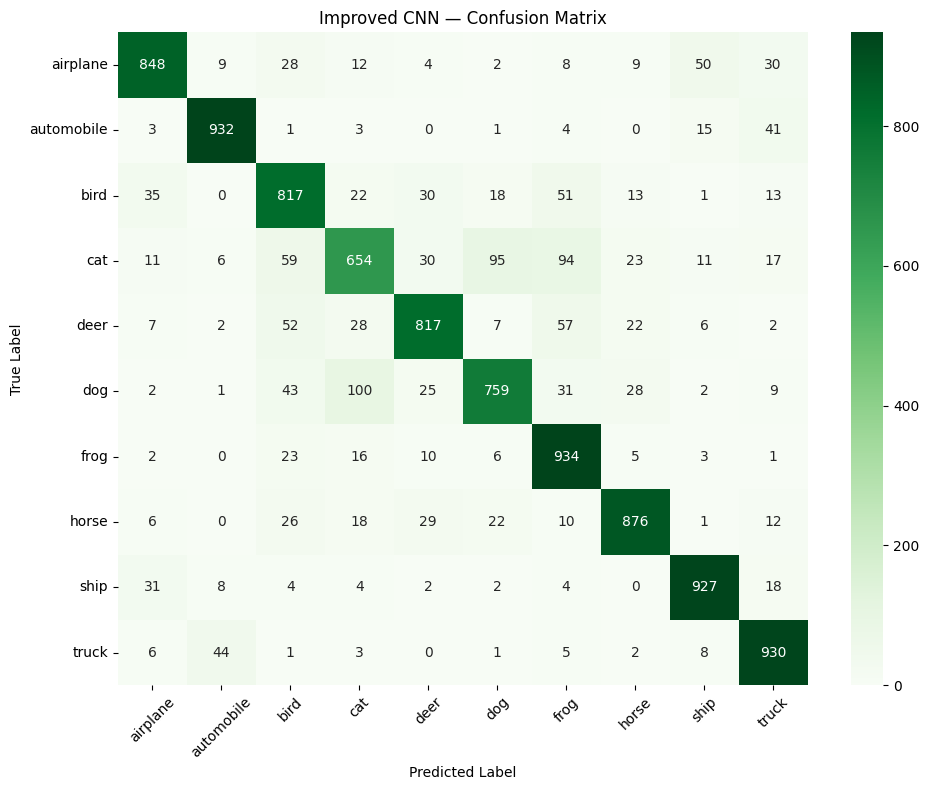

In [9]:
cm_imp = confusion_matrix(y_true, y_pred_classes_imp)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_imp, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Improved CNN — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('improved_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print("=" * 65)
print("TASK 1 — FINAL COMPARISON: BASELINE vs IMPROVED CNN")
print("=" * 65)
print(f"{'Metric':<30} {'Baseline (Part A)':<20} {'Improved (Part B)'}")
print("-" * 65)
print(f"{'Test Accuracy':<30} {'72.14%':<20} {test_acc_imp*100:.2f}%")
print(f"{'Training Time (sec)':<30} {'138.94':<20} {training_time_improved:.2f}")
print(f"{'Epochs':<30} {'12':<20} {len(history_improved.history['accuracy'])}")
print(f"{'Parameters':<30} {'5,870,666':<20} {improved_model.count_params():,}")
print("-" * 65)
print(f"Improvement: {(test_acc_imp - 0.7214)*100:.2f} percentage points")
print("=" * 65)

TASK 1 — FINAL COMPARISON: BASELINE vs IMPROVED CNN
Metric                         Baseline (Part A)    Improved (Part B)
-----------------------------------------------------------------
Test Accuracy                  72.14%               84.94%
Training Time (sec)            138.94               335.43
Epochs                         12                   12
Parameters                     5,870,666            5,874,250
-----------------------------------------------------------------
Improvement: 12.80 percentage points
